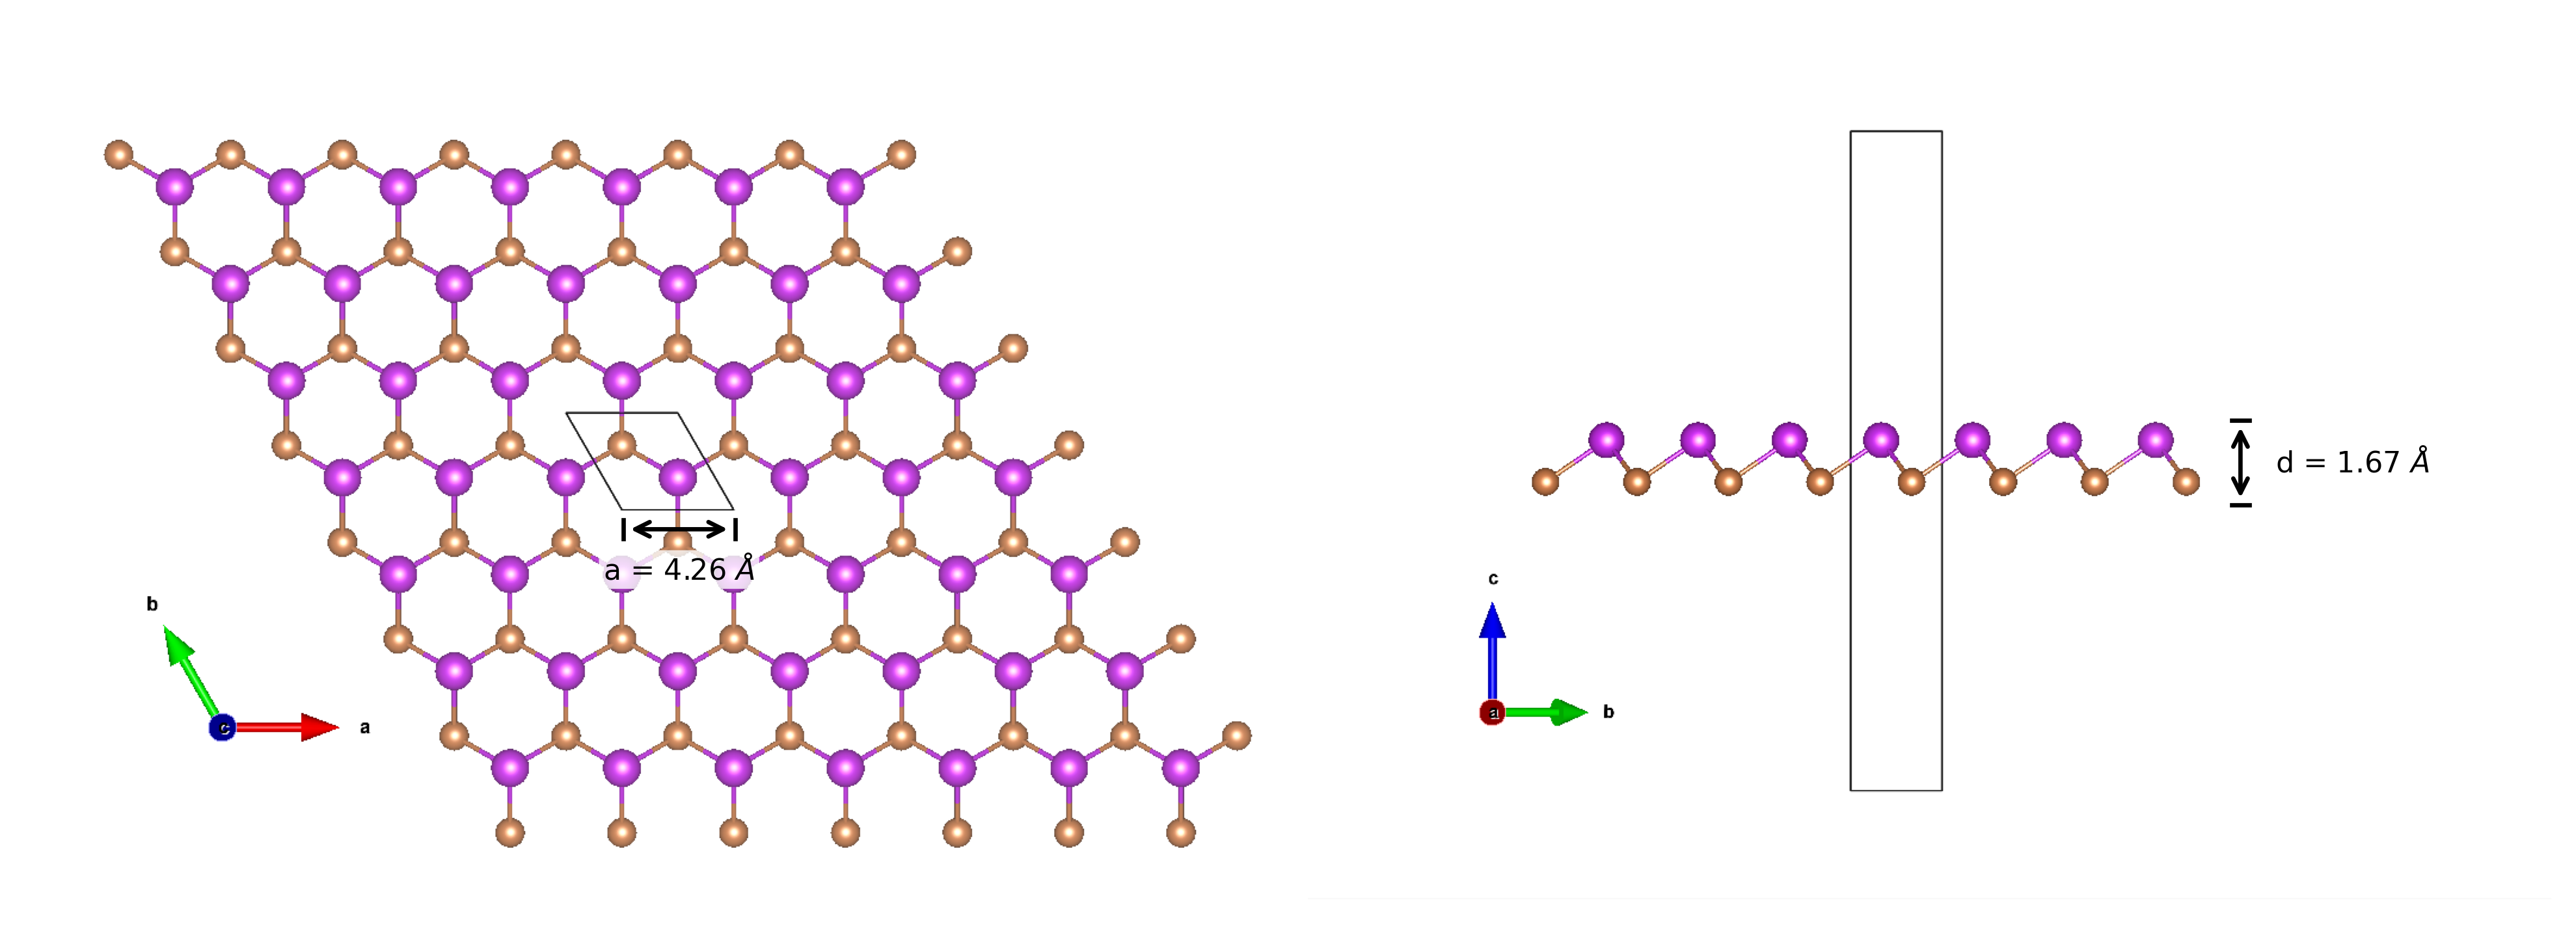

Saved → BiSb_monolayer.png


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

im1 = Image.open("a.png")
im2 = Image.open("b.png")

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=400)

ax[0].imshow(im1)
ax[1].imshow(im2)
ax[0].axis("off")
ax[1].axis("off")


def draw_arrow(ax, x1, y1, x2, y2, color="black", lw=1.2, ticks=True, tick_len=8):
    """
    Draw a double-headed arrow from (x1, y1) to (x2, y2) in pixel coordinates.

    Parameters
    ----------
    ax        : matplotlib Axes
    x1, y1   : start point (pixels)
    x2, y2   : end point (pixels)
    color     : arrow color
    lw        : line width
    ticks     : whether to draw small perpendicular tick marks at each end
    tick_len  : half-length of tick marks in pixels
    """
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                xycoords="data", textcoords="data",
                arrowprops=dict(arrowstyle="<->", color=color, lw=lw))

    if ticks:
        # Perpendicular direction
        dx, dy = x2 - x1, y2 - y1
        length = np.hypot(dx, dy)
        px, py = -dy / length * tick_len, dx / length * tick_len
        for xk, yk in [(x1, y1), (x2, y2)]:
            ax.plot([xk - px, xk + px], [yk - py, yk + py], color=color, lw=lw)


def draw_label(ax, x, y, text, color="black", fontsize=7, ha="center", va="center",
               bg=True, bg_alpha=0.8):
    """
    Draw a text label at (x, y) in pixel coordinates.

    Parameters
    ----------
    ax        : matplotlib Axes
    x, y      : position (pixels)
    text      : label string (LaTeX supported, e.g. r'$\\Delta$')
    color     : text color
    fontsize  : font size
    ha, va    : horizontal / vertical alignment
    bg        : whether to draw a white background box behind the text
    bg_alpha  : opacity of the background box
    """
    bbox = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=bg_alpha) if bg else None
    ax.text(x, y, text, color=color, fontsize=fontsize,
            ha=ha, va=va, bbox=bbox)


# ── Image dimensions ────────────────────────────────────────────────────────
h1, w1 = np.array(im1).shape[:2]
h2, w2 = np.array(im2).shape[:2]

# ════════════════════════════════════════════════════════════════════
# LEFT IMAGE — top view

# Lattice constant 'a'  (horizontal arrow)
lc_y  = h1 * 0.56
lc_x1 = w1 * 0.48
lc_x2 = w1 * 0.57
draw_arrow(ax[0], lc_x1, lc_y, lc_x2, lc_y, color="#000000")
draw_label(ax[0], (lc_x1 + lc_x2) / 2, lc_y + lc_y * 0.08, r'a = 4.26 $\AA$', color="#000000", fontsize=8)

# ════════════════════════════════════════════════════════════════════
# RIGHT IMAGE — side view

# Buckling distance Δ  (vertical arrow)
bk_x  = w2 * 0.75
bk_y1 = h2 * 0.435
bk_y2 = h2 * 0.535
draw_arrow(ax[1], bk_x, bk_y1, bk_x, bk_y2, color="#000000")
draw_label(ax[1], bk_x*1.12, (bk_y1 + bk_y2) / 2, r"d = 1.67 $\AA$", color="#000000", fontsize=8)

plt.tight_layout()
plt.savefig("BiSb_monolayer.png", bbox_inches="tight", dpi=400)
plt.show()
print("Saved → BiSb_monolayer.png")

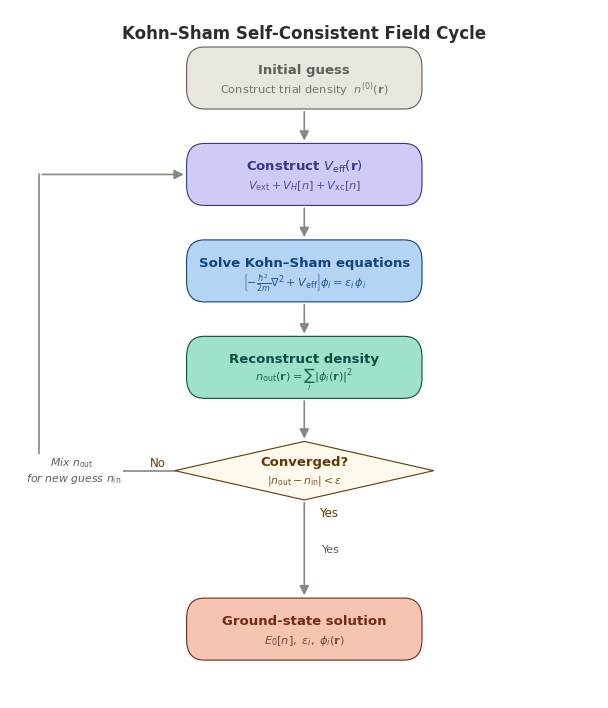

In [11]:
"""
Kohn-Sham SCF Cycle Schematic
Plots the self-consistent field loop as a publication-quality flowchart.
Dependencies: matplotlib, numpy
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np

# ── colour palette ────────────────────────────────────────────────────────────
GRAY   = ("#E8E6DF", "#5F5E5A")   # (fill, text)
PURPLE = ("#CECBF6", "#3C3489")
BLUE   = ("#B5D4F4", "#0C447C")
TEAL   = ("#9FE1CB", "#085041")
CORAL  = ("#F5C4B3", "#712B13")
DIAM   = ("#FFF8ED", "#633806")   # decision diamond (amber-ish)

ARROW_COLOR  = "#888780"
BORDER_COLOR = "#B4B2A9"
BG_COLOR     = "white"
FONT         = "DejaVu Sans"

# ── layout constants ──────────────────────────────────────────────────────────
FIG_W, FIG_H = 6, 7
CX   = 0.50        # centre x for main column
BW   = 0.4         # box width  (axes fraction)
BH   = 0.09        # box height
GAP  = 0.05        # vertical gap between boxes
PAD  = 0.012       # inner text padding

# y-centres of each main box (top → bottom)
Y = {}
Y["init"]    = 0.90
Y["veff"]    = Y["init"]  - BH - GAP
Y["ks"]      = Y["veff"]  - BH - GAP
Y["density"] = Y["ks"]    - BH - GAP
Y["conv"]    = Y["density"]- BH - GAP - 0.01   # diamond sits lower
Y["output"]  = 0.1

# ── helpers ───────────────────────────────────────────────────────────────────

def rounded_box(ax, cx, cy, w, h, fill, edge, label, sublabel=None, r=0.03):
    """Draw a rounded rectangle with a bold title and optional subtitle."""
    x = cx - w / 2
    y = cy - h / 2
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0,rounding_size={r}",
        linewidth=0.8, edgecolor=edge, facecolor=fill,
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(box)
    if sublabel:
        ax.text(cx, cy + h * 0.14, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
        ax.text(cx, cy - h * 0.18, sublabel,
                ha="center", va="center",
                fontsize=8.2, color=edge, alpha=0.85,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
    else:
        ax.text(cx, cy, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def diamond(ax, cx, cy, w, h, fill, edge, label, sublabel=None):
    """Draw a diamond (decision) shape."""
    hw, hh = w / 2, h / 2
    xs = [cx, cx + hw, cx, cx - hw, cx]
    ys = [cy + hh, cy, cy - hh, cy, cy + hh]
    coords = list(zip(xs, ys))
    patch = plt.Polygon(
        coords, closed=True,
        linewidth=0.8, edgecolor=edge, facecolor=fill,
        transform=ax.transAxes, zorder=3
    )
    ax.add_patch(patch)
    if sublabel:
        ax.text(cx, cy + hh * 0.32, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
        ax.text(cx, cy - hh * 0.32, sublabel,
                ha="center", va="center",
                fontsize=7.8, color=edge, alpha=0.85,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)
    else:
        ax.text(cx, cy, label,
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color=edge,
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def arrow(ax, x1, y1, x2, y2, label=None, label_side="right"):
    """Draw a straight arrow between two axes-fraction points."""
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=ARROW_COLOR,
            lw=1.2,
            mutation_scale=14,
        ),
        zorder=2
    )
    if label:
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        dx = 0.03 if label_side == "right" else -0.03
        ax.text(mx + dx, my, label,
                ha="left" if label_side == "right" else "right",
                va="center", fontsize=8, color="#5F5E5A",
                fontfamily=FONT, transform=ax.transAxes, zorder=4)


def polyline_arrow(ax, points, label=None, label_pos=0.5):
    """Draw a multi-segment arrow through a list of (x,y) axes-fraction points."""
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax.plot(xs[:-1], ys[:-1], color=ARROW_COLOR, lw=1.2,
            transform=ax.transAxes, zorder=2, solid_capstyle="round")
    ax.annotate(
        "", xy=points[-1], xytext=points[-2],
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color=ARROW_COLOR,
            lw=1.2,
            mutation_scale=14,
        ),
        zorder=2
    )
    if label:
        idx = max(0, int(len(points) * label_pos) - 1)
        lx = (xs[idx] + xs[idx + 1]) / 2 - 0.06
        ly = (ys[idx] + ys[idx + 1]) / 2
        ax.text(lx, ly, label,
                ha="center", va="center",
                fontsize=7.8, color="#5F5E5A", style="italic",
                fontfamily=FONT, transform=ax.transAxes,
                bbox=dict(facecolor=BG_COLOR, edgecolor="none", pad=1.5),
                zorder=5)


# ── figure ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ── title ─────────────────────────────────────────────────────────────────────
ax.text(CX, 0.965, "Kohn–Sham Self-Consistent Field Cycle",
        ha="center", va="center",
        fontsize=12, fontweight="bold", color="#2C2C2A",
        fontfamily=FONT, transform=ax.transAxes)

# ── boxes ─────────────────────────────────────────────────────────────────────

# 1. Initial guess
rounded_box(ax, CX, Y["init"], BW, BH,
            fill=GRAY[0], edge=GRAY[1],
            label="Initial guess",
            sublabel=r"Construct trial density  $n^{(0)}(\mathbf{r})$")

# 2. Construct V_eff
rounded_box(ax, CX, Y["veff"], BW, BH,
            fill=PURPLE[0], edge=PURPLE[1],
            label=r"Construct $V_\mathrm{eff}(\mathbf{r})$",
            sublabel=r"$V_\mathrm{ext} + V_H[n] + V_\mathrm{xc}[n]$")

# 3. Solve KS equations
rounded_box(ax, CX, Y["ks"], BW, BH,
            fill=BLUE[0], edge=BLUE[1],
            label="Solve Kohn–Sham equations",
            sublabel=r"$\left[-\frac{\hbar^2}{2m}\nabla^2 + V_\mathrm{eff}\right]\phi_i = \varepsilon_i\,\phi_i$")

# 4. Reconstruct density
rounded_box(ax, CX, Y["density"], BW, BH,
            fill=TEAL[0], edge=TEAL[1],
            label="Reconstruct density",
            sublabel=r"$n_\mathrm{out}(\mathbf{r}) = \sum_i |\phi_i(\mathbf{r})|^2$")

# 5. Convergence diamond
DW, DH = 0.44, 0.085
diamond(ax, CX, Y["conv"], DW, DH,
        fill=DIAM[0], edge=DIAM[1],
        label="Converged?",
        sublabel=r"$|n_\mathrm{out} - n_\mathrm{in}| < \varepsilon$")

# 6. Output
rounded_box(ax, CX, Y["output"], BW, BH,
            fill=CORAL[0], edge=CORAL[1],
            label="Ground-state solution",
            sublabel=r"$E_0[n],\; \varepsilon_i,\; \phi_i(\mathbf{r})$")

# ── straight arrows (main column) ─────────────────────────────────────────────

# init → veff
arrow(ax, CX, Y["init"]  - BH/2,
          CX, Y["veff"]  + BH/2)

# veff → ks
arrow(ax, CX, Y["veff"]  - BH/2,
          CX, Y["ks"]    + BH/2)

# ks → density
arrow(ax, CX, Y["ks"]    - BH/2,
          CX, Y["density"]+ BH/2)

# density → diamond
arrow(ax, CX, Y["density"]- BH/2,
          CX, Y["conv"]   + DH/2)

# diamond → output (Yes, downward)
arrow(ax, CX, Y["conv"] - DH/2,
          CX, Y["output"] + BH/2,
     label="Yes", label_side="right")

# ── feedback loop (No branch) ─────────────────────────────────────────────────
# From left vertex of diamond → left margin → back up to V_eff box

LEFT_X   = CX - DW / 2          # left tip of diamond
MARGIN_X = 0.05                  # x of the vertical return rail
TOP_Y    = Y["veff"]             # re-enter at V_eff mid-height

polyline_arrow(
    ax,
    [(LEFT_X, Y["conv"]),
     (MARGIN_X, Y["conv"]),
     (MARGIN_X, TOP_Y),
     (CX - BW/2, TOP_Y)],
    label="Mix $n_\\mathrm{out}$\n for new guess $n_\\mathrm{in}$",
    label_pos=0.45
)

# ── Yes / No labels near diamond ──────────────────────────────────────────────
ax.text(CX - DW/2 - 0.015, Y["conv"] + 0.012, "No",
        ha="right", va="center", fontsize=8.5, color=DIAM[1],
        fontfamily=FONT, transform=ax.transAxes)

ax.text(CX + 0.025, Y["conv"] - DH/2 - 0.018, "Yes",
        ha="left", va="center", fontsize=8.5, color=DIAM[1],
        fontfamily=FONT, transform=ax.transAxes)



plt.tight_layout(pad=0.4)
plt.savefig("scf_cycle.png", dpi=300, bbox_inches="tight")
plt.show()